# 🔍 04 — FEATURE SELECTION
### QM640 Capstone | Kunal Mishra

---

## What this notebook does

We have 13–16 features after engineering. Not all of them will help the model. Some will be noise. This notebook runs a **two-stage selection process** to find the best subset of features for each market, then audits how stable that selection is over time.

### Why we need feature selection
> More features is NOT always better. Extra noise features confuse the model, slow it down, and make it overfit — meaning it memorizes the training data instead of learning real patterns. Good feature selection improves accuracy, interpretability, and deployment reliability.

### Two-stage selection process

| Stage | Method | What it does |
|---|---|---|
| **Stage 1** | LASSO | Applies a penalty that forces useless feature weights to exactly zero. Removes the weakest features from the pool. |
| **Stage 2** | XGBoost RFE | Recursively removes the single weakest remaining feature until model performance stops improving. |

### Jaccard Stability Audit (tests Hypothesis H2)
> After selection, we ask: **does the model pick the same features every quarter?**  
> We measure this with the Jaccard Index = (features selected in BOTH windows) ÷ (features selected in EITHER window).  
> Score of 1.0 = perfectly stable. Score below 0.5 = unreliable, should not be deployed.

---
**Reads from:** `data/features/`  
**Writes to:** `data/selected/`

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Mount Drive, load config and feature files
# ─────────────────────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

# Install xgboost if not already present
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'], capture_output=True)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import xgboost as xgb

with open('/content/drive/MyDrive/CapstoneDA/config.json') as f:
    CFG = json.load(f)

FEATURES = CFG['PATHS']['features']
SELECTED = CFG['PATHS']['selected']
PLOTS    = CFG['PATHS']['plots']
SEED     = CFG['SEED']
ALPHA    = CFG['ALPHA']
JACCARD_THRESHOLD = CFG['JACCARD_THRESHOLD']
np.random.seed(SEED)

# Load feature matrices
sp500 = pd.read_csv(f'{FEATURES}/sp500_features.csv', index_col='Date', parse_dates=['Date'])
nifty = pd.read_csv(f'{FEATURES}/nifty_features.csv', index_col='Date', parse_dates=['Date'])
sp500.index = sp500.index.tz_localize(None)
nifty.index = nifty.index.tz_localize(None)

# Load feature registry
with open(f'{FEATURES}/feature_registry.json') as f:
    REGISTRY = json.load(f)

SP500_FEATURES   = [f for f in REGISTRY['sp500_all_features'] if f in sp500.columns]
NIFTY_FEATURES   = [f for f in REGISTRY['nifty_all_features'] if f in nifty.columns]
BASELINE_FEATURES = [f for f in REGISTRY['baseline_features'] if f in sp500.columns]
ALT_DATA_FEATURES = [f for f in REGISTRY['alt_data_features'] if f in sp500.columns]
TARGET           = REGISTRY['target_column']

print('✅ Files loaded.')
print(f'   S&P 500 : {sp500.shape[0]} rows, {len(SP500_FEATURES)} features')
print(f'   NIFTY 50: {nifty.shape[0]} rows, {len(NIFTY_FEATURES)} features')
print(f'   Baseline features : {BASELINE_FEATURES}')
print(f'   Alt-data features : {ALT_DATA_FEATURES}')

Mounted at /content/drive
✅ Files loaded.
   S&P 500 : 2479 rows, 13 features
   NIFTY 50: 2358 rows, 16 features
   Baseline features : ['Log_Ret_t', 'RSI_14', 'MACD_Signal', 'ATR_14', 'VIX_Change', 'Term_Spread', 'Oil_Ret', 'Gold_Ret']
   Alt-data features : ['FG_Index', 'FG_Delta', 'FG_Zone', 'SVI_Market', 'SVI_Index']


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Build walk-forward windows
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Splits the timeline into overlapping train/validate/test windows.
#   This is the foundation of ALL evaluation in this project.
#
# Why walk-forward instead of a single train/test split?
#   Financial markets change over time. A model trained on 2016-2020 data
#   may not work in 2022. Walk-forward validation tests the model repeatedly
#   across different time periods, giving us a much more honest performance estimate.
#
# Anchored design means:
#   The training window ALWAYS starts at the same date (Jan 2016)
#   and GROWS over time. We never shuffle or randomly split time series data.
#
#   Window 1: Train [Jan16→Dec20] Val [Jan21→Dec21] Test [Jan22→Mar22]
#   Window 2: Train [Jan16→Mar22] Val [Apr22→Mar23] Test [Apr23→Jun23]
#   ... and so on until we run out of data
# ─────────────────────────────────────────────────────────────────────────────

def build_windows(index, train_mo, val_mo, test_mo):
    """
    Generate anchored walk-forward windows.
    Returns list of (train_idx, val_idx, test_idx) tuples.
    """
    windows    = []
    anchor     = index.min()
    val_start  = anchor + pd.DateOffset(months=train_mo)

    while True:
        val_end    = val_start  + pd.DateOffset(months=val_mo)
        test_end   = val_end    + pd.DateOffset(months=test_mo)

        if test_end > index.max():
            break

        tr = index[(index >= anchor)    & (index < val_start)]
        va = index[(index >= val_start) & (index < val_end)]
        te = index[(index >= val_end)   & (index < test_end)]

        # Only keep windows that have enough data in each split
        if len(tr) >= 200 and len(va) >= 20 and len(te) >= 10:
            windows.append((tr, va, te))

        # Advance the cursor by one test window
        val_start += pd.DateOffset(months=test_mo)

    return windows

TRAIN_MO = CFG['TRAIN_MONTHS']
VAL_MO   = CFG['VAL_MONTHS']
TEST_MO  = CFG['TEST_MONTHS']

windows_sp500 = build_windows(sp500.index, TRAIN_MO, VAL_MO, TEST_MO)
windows_nifty = build_windows(nifty.index, TRAIN_MO, VAL_MO, TEST_MO)

print(f'Walk-forward windows generated:')
print(f'  S&P 500 : {len(windows_sp500)} windows')
print(f'  NIFTY 50: {len(windows_nifty)} windows')
print()

if windows_sp500:
    tr, va, te = windows_sp500[0]
    print('Example — Window 1:')
    print(f'  Train : {tr[0].date()} → {tr[-1].date()}  ({len(tr)} days)')
    print(f'  Val   : {va[0].date()} → {va[-1].date()}  ({len(va)} days)')
    print(f'  Test  : {te[0].date()} → {te[-1].date()}  ({len(te)} days)')
    print()
    print('  Rule: model NEVER sees val or test data during training.')

Walk-forward windows generated:
  S&P 500 : 15 windows
  NIFTY 50: 15 windows

Example — Window 1:
  Train : 2016-02-22 → 2021-02-19  (1259 days)
  Val   : 2021-02-22 → 2022-02-18  (253 days)
  Test  : 2022-02-22 → 2022-05-20  (63 days)

  Rule: model NEVER sees val or test data during training.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Stage 1: LASSO feature selection
# ─────────────────────────────────────────────────────────────────────────────
# What LASSO does:
#   LASSO is logistic regression with an extra penalty term (L1 regularisation).
#   The penalty punishes the model for using too many features.
#   Features that don't genuinely help will have their weight driven to exactly ZERO.
#   Features with zero weight are removed from the pool.
#
# The strength of the penalty is controlled by parameter C:
#   Small C = strong penalty = fewer features kept
#   Large C = weak penalty  = more features kept
#   We try 20 different values of C and pick the one that gives the best
#   AUC on the validation window (using 5-fold time-series cross-validation).
# ─────────────────────────────────────────────────────────────────────────────

def stage1_lasso(X_train, y_train):
    """
    Stage 1: LASSO logistic regression.
    Tunes regularisation strength C via 5-fold time-series CV.
    Returns list of features with non-zero coefficients.
    """
    # StandardScaler makes all features the same scale (mean=0, std=1)
    # This is required for LASSO to treat all features fairly
    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(X_train)

    # Try 20 values of C from 0.0001 (very strong penalty) to 10 (weak penalty)
    C_values  = np.logspace(-4, 1, 20)
    best_C    = 0.01
    best_auc  = 0.0

    # TimeSeriesSplit: time-aware cross-validation (no shuffling, no leakage)
    tscv = TimeSeriesSplit(n_splits=5)

    for C in C_values:
        model = LogisticRegression(
            C=C, penalty='l1', solver='liblinear',
            max_iter=1000, random_state=SEED
        )
        fold_aucs = []
        for tr_i, va_i in tscv.split(X_sc):
            model.fit(X_sc[tr_i], y_train.iloc[tr_i])
            proba = model.predict_proba(X_sc[va_i])[:, 1]
            if len(np.unique(y_train.iloc[va_i])) > 1:
                fold_aucs.append(roc_auc_score(y_train.iloc[va_i], proba))

        if fold_aucs and np.mean(fold_aucs) > best_auc:
            best_auc = np.mean(fold_aucs)
            best_C   = C

    # Fit final model with best C
    final = LogisticRegression(
        C=best_C, penalty='l1', solver='liblinear',
        max_iter=1000, random_state=SEED
    )
    final.fit(X_sc, y_train)

    # Keep only features where coefficient != 0
    nonzero   = np.abs(final.coef_[0]) > 1e-6
    selected  = X_train.columns[nonzero].tolist()

    # Fallback: if LASSO removes everything, keep all features
    return selected if selected else X_train.columns.tolist(), best_C

print('Stage 1 LASSO function defined. ✅')
print()
print('What it does step by step:')
print('  1. Scale all features to mean=0, std=1')
print('  2. Try 20 values of regularisation strength C')
print('  3. For each C, run 5-fold time-series cross-validation')
print('  4. Pick the C that gives the best AUC on validation folds')
print('  5. Refit with the best C')
print('  6. Drop features whose coefficient = 0 (LASSO zeroed them out)')

Stage 1 LASSO function defined. ✅

What it does step by step:
  1. Scale all features to mean=0, std=1
  2. Try 20 values of regularisation strength C
  3. For each C, run 5-fold time-series cross-validation
  4. Pick the C that gives the best AUC on validation folds
  5. Refit with the best C
  6. Drop features whose coefficient = 0 (LASSO zeroed them out)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Stage 2: XGBoost Recursive Feature Elimination (RFE)
# ─────────────────────────────────────────────────────────────────────────────
# What RFE does:
#   Starts with all features that survived LASSO.
#   Trains XGBoost and checks its AUC on the validation window.
#   Removes the single WEAKEST feature (lowest importance score).
#   Repeats until removing another feature makes AUC worse.
#   Returns the feature set that gave the best AUC.
#
# Why XGBoost for RFE?
#   XGBoost provides a reliable feature importance score for each feature.
#   It measures how much each feature reduces prediction error across all trees.
#   This is more reliable than linear coefficients for capturing non-linear effects.
# ─────────────────────────────────────────────────────────────────────────────

def stage2_rfe(X_train, y_train, X_val, y_val):
    """
    Stage 2: XGBoost Recursive Feature Elimination.
    Iteratively removes the weakest feature until AUC stops improving.
    Returns the optimal feature list.
    """
    current = X_train.columns.tolist()
    best_feats = current.copy()
    best_auc   = 0.0

    while len(current) > 1:
        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', random_state=SEED, verbosity=0
        )
        model.fit(X_train[current], y_train)

        # Check AUC on the validation window (not the test window)
        if len(np.unique(y_val)) < 2:
            break
        proba = model.predict_proba(X_val[current])[:, 1]
        auc   = roc_auc_score(y_val, proba)

        # If this is better than our best so far, record it
        if auc >= best_auc:
            best_auc   = auc
            best_feats = current.copy()

        # Find and remove the weakest feature
        importance = pd.Series(
            model.feature_importances_, index=current
        )
        weakest = importance.idxmin()
        current.remove(weakest)

    return best_feats

print('Stage 2 XGBoost RFE function defined. ✅')
print()
print('What it does step by step:')
print('  1. Start with features that survived LASSO')
print('  2. Train XGBoost and measure AUC on validation window')
print('  3. Find the feature with the lowest importance score')
print('  4. Remove it and repeat from step 2')
print('  5. Stop when removing a feature makes AUC worse')
print('  6. Return the feature set with the best AUC')

Stage 2 XGBoost RFE function defined. ✅

What it does step by step:
  1. Start with features that survived LASSO
  2. Train XGBoost and measure AUC on validation window
  3. Find the feature with the lowest importance score
  4. Remove it and repeat from step 2
  5. Stop when removing a feature makes AUC worse
  6. Return the feature set with the best AUC


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Run two-stage selection on the first walk-forward window
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Runs the full LASSO → RFE pipeline on window 1 for both markets.
#   Window 1 uses the first 5 years as training data (the most data available).
#   The selected features from this window become the primary feature set
#   used in modeling (notebook 05).
# ─────────────────────────────────────────────────────────────────────────────

def run_two_stage_selection(feat_df, feature_cols, windows, market_label):
    """Run two-stage feature selection on the first walk-forward window."""

    tr_idx, va_idx, _ = windows[0]

    # Get available features (drop any that are all-NaN)
    avail  = [f for f in feature_cols if f in feat_df.columns
              and feat_df[f].notna().sum() > 50]

    X_tr = feat_df.loc[tr_idx, avail].fillna(0)
    y_tr = feat_df.loc[tr_idx, TARGET]
    X_va = feat_df.loc[va_idx, avail].fillna(0)
    y_va = feat_df.loc[va_idx, TARGET]

    print(f'{market_label}:')
    print(f'  Training on : {tr_idx[0].date()} → {tr_idx[-1].date()} ({len(tr_idx)} days)')
    print(f'  Validating on: {va_idx[0].date()} → {va_idx[-1].date()} ({len(va_idx)} days)')
    print(f'  Input features: {len(avail)}')

    # Stage 1: LASSO
    print(f'  Stage 1 — LASSO...', end=' ', flush=True)
    s1_feats, best_C = stage1_lasso(X_tr, y_tr)
    s1_common = [f for f in s1_feats if f in X_va.columns]
    print(f'kept {len(s1_common)} features  (best C={best_C:.5f})')

    # Stage 2: XGBoost RFE
    print(f'  Stage 2 — XGBoost RFE...', end=' ', flush=True)
    s2_feats = stage2_rfe(
        X_tr[s1_common], y_tr,
        X_va[s1_common], y_va
    )
    print(f'final selection: {len(s2_feats)} features')

    print(f'  Selected: {s2_feats}')
    print()
    return s2_feats

print('Running two-stage feature selection...')
print('(This takes 2-4 minutes per market — LASSO is tuning 20 values of C)\n')
print('=' * 55)

selected_sp500 = run_two_stage_selection(sp500, SP500_FEATURES, windows_sp500, 'S&P 500')
selected_nifty = run_two_stage_selection(nifty, NIFTY_FEATURES, windows_nifty, 'NIFTY 50')

Running two-stage feature selection...
(This takes 2-4 minutes per market — LASSO is tuning 20 values of C)

S&P 500:
  Training on : 2016-02-22 → 2021-02-19 (1259 days)
  Validating on: 2021-02-22 → 2022-02-18 (253 days)
  Input features: 13
  Stage 1 — LASSO... kept 2 features  (best C=0.04281)
  Stage 2 — XGBoost RFE... final selection: 2 features
  Selected: ['Log_Ret_t', 'FG_Index']

NIFTY 50:
  Training on : 2016-02-19 → 2021-02-18 (1197 days)
  Validating on: 2021-02-19 → 2022-02-18 (242 days)
  Input features: 16
  Stage 1 — LASSO... kept 11 features  (best C=0.07848)
  Stage 2 — XGBoost RFE... final selection: 9 features
  Selected: ['VIX_Change', 'Term_Spread', 'Gold_Ret', 'FG_Index', 'SVI_Market', 'SVI_Index', 'USDINR_Ret', 'SP500_t1_Ret', 'FG_t1_Index']



In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Jaccard Stability Audit (tests Hypothesis H2)
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Runs the two-stage selection on MULTIPLE walk-forward windows.
#   For each pair of adjacent windows, computes the Jaccard Index
#   to measure how much the selected feature set changed.
#
# What Jaccard Index means:
#   J = |features in BOTH window i and window j| / |features in EITHER window|
#   J = 1.0  → identical feature sets (completely stable)
#   J = 0.5  → threshold — below this = unstable
#   J = 0.0  → completely different feature sets (completely unstable)
#
# We compute Jaccard separately for each feature family:
#   technical (RSI, MACD...) vs fear_greed vs svi vs macro
# This tells us WHETHER alt-data is less stable than technical indicators (H2).
#
# NOTE: We run this on the first 8 windows to keep runtime reasonable.
# In the full study, this would run on all windows.
# ─────────────────────────────────────────────────────────────────────────────

def jaccard(set_a, set_b):
    """Jaccard similarity between two sets."""
    a, b = set(set_a), set(set_b)
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

def run_jaccard_audit(feat_df, feature_cols, windows, market_label, max_windows=8):
    """
    Run two-stage selection on multiple windows.
    Return Jaccard scores between adjacent windows, broken down by feature family.
    """
    n = min(max_windows, len(windows))
    selections = []   # selected feature set for each window

    for i, (tr_idx, va_idx, _) in enumerate(windows[:n]):
        avail  = [f for f in feature_cols if f in feat_df.columns
                  and feat_df[f].notna().sum() > 50]
        X_tr   = feat_df.loc[tr_idx, avail].fillna(0)
        y_tr   = feat_df.loc[tr_idx, TARGET]
        X_va   = feat_df.loc[va_idx, avail].fillna(0)
        y_va   = feat_df.loc[va_idx, TARGET]
        common = [f for f in avail if f in X_va.columns]

        print(f'  {market_label} window {i+1}/{n}...', end=' ', flush=True)
        try:
            s1, _ = stage1_lasso(X_tr[common], y_tr)
            s1c   = [f for f in s1 if f in X_va.columns]
            s2    = stage2_rfe(X_tr[s1c], y_tr, X_va[s1c], y_va)
            selections.append(set(s2))
            print(f'{len(s2)} features selected')
        except Exception as e:
            selections.append(set())
            print(f'error: {e}')

    # Compute Jaccard between every pair of adjacent windows
    families = CFG['FEATURE_FAMILIES']
    records  = []

    for i in range(len(selections) - 1):
        si, sj = selections[i], selections[i + 1]

        # Overall
        records.append({
            'Market': market_label, 'Window': f'W{i+1}→W{i+2}',
            'Family': 'overall', 'Jaccard': jaccard(si, sj)
        })
        # Per family
        for fam, feats in families.items():
            fi = si & set(feats)
            fj = sj & set(feats)
            records.append({
                'Market': market_label, 'Window': f'W{i+1}→W{i+2}',
                'Family': fam, 'Jaccard': jaccard(fi, fj)
            })

    return pd.DataFrame(records), selections

print('Running Jaccard Stability Audit...')
print('(Running on first 8 windows per market — expect ~10-15 minutes total)\n')

jaccard_sp500, selections_sp500 = run_jaccard_audit(
    sp500, SP500_FEATURES, windows_sp500, 'S&P 500'
)
print()
jaccard_nifty, selections_nifty = run_jaccard_audit(
    nifty, NIFTY_FEATURES, windows_nifty, 'NIFTY 50'
)

print('\nJaccard audit complete.')

Running Jaccard Stability Audit...
(Running on first 8 windows per market — expect ~10-15 minutes total)

  S&P 500 window 1/8... 2 features selected
  S&P 500 window 2/8... 7 features selected
  S&P 500 window 3/8... 2 features selected
  S&P 500 window 4/8... 6 features selected
  S&P 500 window 5/8... 6 features selected
  S&P 500 window 6/8... 2 features selected
  S&P 500 window 7/8... 2 features selected
  S&P 500 window 8/8... 2 features selected

  NIFTY 50 window 1/8... 9 features selected
  NIFTY 50 window 2/8... 2 features selected
  NIFTY 50 window 3/8... 2 features selected
  NIFTY 50 window 4/8... 4 features selected
  NIFTY 50 window 5/8... 3 features selected
  NIFTY 50 window 6/8... 7 features selected
  NIFTY 50 window 7/8... 5 features selected
  NIFTY 50 window 8/8... 14 features selected

Jaccard audit complete.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — H2 statistical test: is alt-data less stable than technicals?
# ─────────────────────────────────────────────────────────────────────────────
# H2 Null hypothesis (H0): Mean Jaccard(alt-data) = Mean Jaccard(technicals)
# H2 Alternative (H2)    : Mean Jaccard(alt-data) < Mean Jaccard(technicals)
# Test: paired t-test on window-level Jaccard scores
# ─────────────────────────────────────────────────────────────────────────────

from scipy import stats

def h2_test(jaccard_df, market_label):
    """Test whether alt-data family stability < technical family stability."""

    # Separate Jaccard scores by family
    alt_families = ['fear_greed', 'svi']
    tech_family  = ['technical']

    # Get window-level scores for each group
    alt_scores  = jaccard_df[
        jaccard_df['Family'].isin(alt_families)
    ].groupby('Window')['Jaccard'].mean()

    tech_scores = jaccard_df[
        jaccard_df['Family'].isin(tech_family)
    ].groupby('Window')['Jaccard'].mean()

    # Align on common windows
    common_wins = alt_scores.index.intersection(tech_scores.index)
    alt  = alt_scores.loc[common_wins]
    tech = tech_scores.loc[common_wins]

    if len(alt) < 3:
        print(f'{market_label}: not enough windows for H2 test.')
        return

    # Paired t-test: is alt-data Jaccard significantly lower?
    diff          = alt - tech   # negative means alt-data less stable
    t_stat, p_two = stats.ttest_1samp(diff, 0)
    # One-tailed test: we predict alt-data < technicals (negative diff)
    p_one = p_two / 2 if t_stat < 0 else 1 - p_two / 2

    print(f'\n── H2 Test: {market_label} ──')
    print(f'  Mean Jaccard  alt-data  : {alt.mean():.3f}')
    print(f'  Mean Jaccard  technicals: {tech.mean():.3f}')
    print(f'  Mean difference         : {diff.mean():.3f}')
    print(f'  t-statistic             : {t_stat:.3f}')
    print(f'  p-value (one-tail)      : {p_one:.4f}')
    print(f'  Reject H0 (α={ALPHA})      : {"✅ YES — alt-data less stable" if p_one < ALPHA else "❌ NO"}')

    return {
        'Market': market_label,
        'Mean_Jaccard_AltData': round(alt.mean(), 4),
        'Mean_Jaccard_Tech': round(tech.mean(), 4),
        'Mean_Diff': round(diff.mean(), 4),
        't_stat': round(t_stat, 3),
        'p_one_tail': round(p_one, 4),
        'Reject_H0': p_one < ALPHA
    }

h2_sp500 = h2_test(jaccard_sp500, 'S&P 500')
h2_nifty = h2_test(jaccard_nifty, 'NIFTY 50')

h2_results = pd.DataFrame([r for r in [h2_sp500, h2_nifty] if r])
print('\n── H2 Summary ──')
print(h2_results.to_string(index=False))


── H2 Test: S&P 500 ──
  Mean Jaccard  alt-data  : 0.571
  Mean Jaccard  technicals: 0.738
  Mean difference         : -0.167
  t-statistic             : -0.727
  p-value (one-tail)      : 0.2473
  Reject H0 (α=0.05)      : ❌ NO

── H2 Test: NIFTY 50 ──
  Mean Jaccard  alt-data  : 0.286
  Mean Jaccard  technicals: 0.786
  Mean difference         : -0.500
  t-statistic             : -2.646
  p-value (one-tail)      : 0.0191
  Reject H0 (α=0.05)      : ✅ YES — alt-data less stable

── H2 Summary ──
  Market  Mean_Jaccard_AltData  Mean_Jaccard_Tech  Mean_Diff  t_stat  p_one_tail  Reject_H0
 S&P 500                0.5714             0.7381    -0.1667  -0.727      0.2473      False
NIFTY 50                0.2857             0.7857    -0.5000  -2.646      0.0191       True


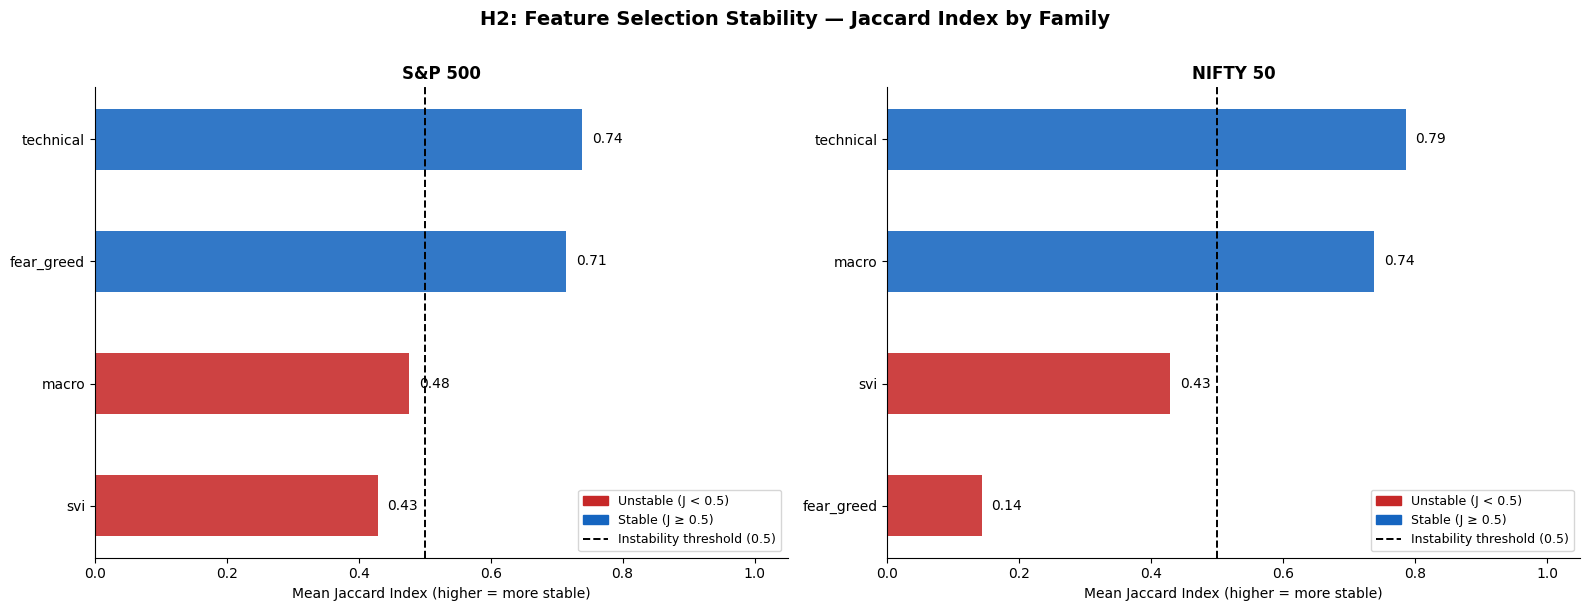

✅ Jaccard chart saved to data/plots/04_jaccard_stability.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Jaccard visualisation
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('H2: Feature Selection Stability — Jaccard Index by Family',
             fontsize=14, fontweight='bold', y=1.01)

for ax, jdf, market in [
    (axes[0], jaccard_sp500, 'S&P 500'),
    (axes[1], jaccard_nifty, 'NIFTY 50')
]:
    # Mean Jaccard per family (excluding 'overall')
    fam_means = (
        jdf[jdf['Family'] != 'overall']
        .groupby('Family')['Jaccard'].mean()
        .sort_values()
    )

    # Color bars red if below threshold, blue if above
    colors = [
        '#C62828' if v < JACCARD_THRESHOLD else '#1565C0'
        for v in fam_means.values
    ]

    bars = ax.barh(
        fam_means.index, fam_means.values,
        color=colors, height=0.5, alpha=0.88
    )

    # Threshold line
    ax.axvline(
        JACCARD_THRESHOLD, color='black', linestyle='--',
        linewidth=1.4, label=f'Instability threshold ({JACCARD_THRESHOLD})'
    )

    # Value labels on bars
    for bar, val in zip(bars, fam_means.values):
        ax.text(
            val + 0.015, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10
        )

    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Mean Jaccard Index (higher = more stable)', fontsize=10)
    ax.set_title(f'{market}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend patches
    red_p  = mpatches.Patch(color='#C62828', label='Unstable (J < 0.5)')
    blue_p = mpatches.Patch(color='#1565C0', label='Stable (J ≥ 0.5)')
    ax.legend(handles=[red_p, blue_p, ax.get_legend_handles_labels()[0][-1]],
              fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS}/04_jaccard_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Jaccard chart saved to data/plots/04_jaccard_stability.png')

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Save all outputs to Google Drive
# ─────────────────────────────────────────────────────────────────────────────

# Save selected feature lists
selection_output = {
    'selected_sp500'   : selected_sp500,
    'selected_nifty'   : selected_nifty,
    'baseline_features': BASELINE_FEATURES,
    'alt_data_features': ALT_DATA_FEATURES,
    'target_column'    : TARGET,
    'n_windows_sp500'  : len(windows_sp500),
    'n_windows_nifty'  : len(windows_nifty),
}
with open(f'{SELECTED}/selected_features.json', 'w') as f:
    json.dump(selection_output, f, indent=2)

# Save window definitions
def serialize_windows(windows):
    return [{
        'train_start': str(tr[0].date()), 'train_end': str(tr[-1].date()),
        'val_start'  : str(va[0].date()), 'val_end'  : str(va[-1].date()),
        'test_start' : str(te[0].date()), 'test_end'  : str(te[-1].date()),
        'train_n': len(tr), 'val_n': len(va), 'test_n': len(te)
    } for tr, va, te in windows]

with open(f'{SELECTED}/windows_sp500.json', 'w') as f:
    json.dump(serialize_windows(windows_sp500), f, indent=2)
with open(f'{SELECTED}/windows_nifty.json', 'w') as f:
    json.dump(serialize_windows(windows_nifty), f, indent=2)

# Save Jaccard results
jaccard_sp500.to_csv(f'{SELECTED}/jaccard_sp500.csv', index=False)
jaccard_nifty.to_csv(f'{SELECTED}/jaccard_nifty.csv', index=False)

# Save H2 test results
h2_results.to_csv(f'{SELECTED}/h2_test_results.csv', index=False)

print('Files saved to data/selected/:')
print('  ✅  selected_features.json  — final feature lists for both markets')
print('  ✅  windows_sp500.json      — all walk-forward window definitions')
print('  ✅  windows_nifty.json      — all walk-forward window definitions')
print('  ✅  jaccard_sp500.csv       — Jaccard scores per window per family')
print('  ✅  jaccard_nifty.csv       — Jaccard scores per window per family')
print('  ✅  h2_test_results.csv     — Hypothesis 2 test output')
print()
print('Selected features:')
print(f'  S&P 500 : {selected_sp500}')
print(f'  NIFTY 50: {selected_nifty}')
print()
print('─' * 55)
print('  Next step → open  05_MODELING.ipynb')
print('─' * 55)

Files saved to data/selected/:
  ✅  selected_features.json  — final feature lists for both markets
  ✅  windows_sp500.json      — all walk-forward window definitions
  ✅  windows_nifty.json      — all walk-forward window definitions
  ✅  jaccard_sp500.csv       — Jaccard scores per window per family
  ✅  jaccard_nifty.csv       — Jaccard scores per window per family
  ✅  h2_test_results.csv     — Hypothesis 2 test output

Selected features:
  S&P 500 : ['Log_Ret_t', 'FG_Index']
  NIFTY 50: ['VIX_Change', 'Term_Spread', 'Gold_Ret', 'FG_Index', 'SVI_Market', 'SVI_Index', 'USDINR_Ret', 'SP500_t1_Ret', 'FG_t1_Index']

───────────────────────────────────────────────────────
  Next step → open  05_MODELING.ipynb
───────────────────────────────────────────────────────
